# Data for the bivariate analysis: commodity prices and tree cover loss

This notebook builds the three files we use for the bivariate analysis and saves them in `data/processed/`:

| File | Unit of observation | Content |
|---|---|---|
| `exposure_weights.csv` | country × commodity | baseline (1996–2000) production of soybeans, palm oil and beef, its value, and each commodity's share in the country's basket |
| `price_index_panel.csv` | country × year | country-specific commodity price index: world real prices weighted by the baseline shares |
| `analysis_panel.csv` | country × year | tree cover loss + price index (current and lagged) + world prices + exposure, ready for scatter plots and correlations |

**Idea.** World prices are the same for every country. A soy boom should only matter for countries that produce soy.
We therefore weight each world price by how much the country produced of that commodity **before** our sample starts (1996–2000),
so that the weights are not themselves affected by deforestation during 2001–2025.

*Inputs: `deforestation_panel.csv` and `commodity_prices_annual.csv` (data/processed), FAOSTAT production via Our World in Data (data/raw/crops).*

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../data/raw/crops/"
PROCESSED = "../data/processed/"

BASELINE = (1996, 2000)   # pre-sample years used for the weights

# commodity name in the price file -> (production file, production column, factor to convert the price to $/tonne)
COMMODITIES = {
    "Soybeans": ("soybean-production.csv", "Soybeans - Production (tonnes)", 1),
    "Palm oil": ("palm-oil-production.csv", "Palm oil - Production (tonnes)", 1),
    "Beef":     ("beef-and-buffalo-meat-production-tonnes.csv", "Beef and buffalo meat - Production (tonnes)", 1000),  # $/kg -> $/t
}

## 1. Load the inputs

### 1.1 Deforestation panel and world prices

In [2]:
defor = pd.read_csv(PROCESSED + "deforestation_panel.csv")
countries = defor[["iso3", "country", "region", "extent_2000_ha"]].drop_duplicates()
print("Deforestation panel:", defor.shape, "|", countries.shape[0], "countries,", defor.year.min(), "-", defor.year.max())

prices = pd.read_csv(PROCESSED + "commodity_prices_annual.csv")
prices = prices[prices["commodity"].isin(COMMODITIES)].copy()
prices["price_real_t"] = prices["price_real"] * prices["commodity"].map({k: v[2] for k, v in COMMODITIES.items()})
prices["log_price_real"] = np.log(prices["price_real_t"])
prices[["commodity", "unit"]].drop_duplicates()

Deforestation panel: (1575, 11) | 63 countries, 2001 - 2025


,commodity,unit
3,Beef,($/kg)
25,Palm oil,($/mt)
37,Soybeans,($/mt)


### 1.2 Production by country (FAOSTAT via Our World in Data)

We keep only the countries of our tropical sample and stack the three commodities in one long table.

In [3]:
prod = []
for commodity, (file, col, _) in COMMODITIES.items():
    p = pd.read_csv(RAW + file).rename(columns={"Code": "iso3", "Year": "year", col: "production_t"})
    p = p[p["iso3"].isin(countries["iso3"])]
    p["commodity"] = commodity
    prod.append(p[["iso3", "commodity", "year", "production_t"]])
prod = pd.concat(prod, ignore_index=True)

# number of sample countries with at least one baseline observation
prod[prod.year.between(*BASELINE)].groupby("commodity")["iso3"].nunique()

commodity
Beef        62
Palm oil    36
Soybeans    43
Name: iso3, dtype: int64

## 2. Exposure weights (country × commodity)

For each country and commodity:
- `prod_base_t`: average production over 1996–2000. A country that does not appear in the file for that commodity produced nothing: we set it to 0.
- `value_base_usd`: baseline production × average real world price over 1996–2000. This puts tonnes of soy, palm oil and beef on the same scale (dollars).
- `share`: the commodity's share in the country's baseline value of the three commodities (sums to 1 within a country).
- `value_per_forest_ha`: total baseline value divided by the 2000 forest extent, to measure *how much* a country is exposed, not only *to what*.

South Sudan did not exist before 2011, so it has no baseline production: its weights are missing.

In [4]:
base_prod = (prod[prod.year.between(*BASELINE)]
             .groupby(["iso3", "commodity"])["production_t"].mean()
             .rename("prod_base_t").reset_index())
base_price = (prices[prices.year.between(*BASELINE)]
              .groupby("commodity")["price_real_t"].mean()
              .rename("price_base_usd_t").reset_index())

# full grid country x commodity, so that non-producers get an explicit 0
grid = pd.MultiIndex.from_product([countries["iso3"], list(COMMODITIES)], names=["iso3", "commodity"]).to_frame(index=False)
weights = grid.merge(base_prod, how="left").merge(base_price, how="left")

has_data = weights.groupby("iso3")["prod_base_t"].transform(lambda s: s.notna().any())
weights.loc[has_data, "prod_base_t"] = weights.loc[has_data, "prod_base_t"].fillna(0)

weights["value_base_usd"] = weights["prod_base_t"] * weights["price_base_usd_t"]
total = weights.groupby("iso3")["value_base_usd"].transform("sum", min_count=1)
weights["share"] = weights["value_base_usd"] / total
weights = weights.merge(countries, on="iso3")
weights["value_per_forest_ha"] = total / weights["extent_2000_ha"]

print("Countries without baseline data:", weights.loc[weights.share.isna(), "iso3"].unique())
weights.pivot(index="iso3", columns="commodity", values="share").round(2).sort_values("Palm oil", ascending=False).head(10)

Countries without baseline data: <StringArray>
['SSD']
Length: 1, dtype: str


commodity,Beef,Palm oil,Soybeans
iso3,,,
MYS,0.01,0.99,0.00
PNG,0.03,0.97,0.00
GNQ,0.04,0.96,0.00
SLB,0.07,0.93,0.00
LBR,0.08,0.89,0.03
CIV,0.22,0.78,0.00
COG,0.24,0.76,0.00
COD,0.23,0.75,0.02
SLE,0.26,0.74,0.00


Dominant commodity per country (largest baseline share):

In [5]:
main = weights.dropna(subset=["share"]).sort_values("share").groupby("iso3").tail(1)
main["commodity"].value_counts()

commodity
Beef        49
Palm oil    12
Soybeans     1
Name: count, dtype: int64

In [6]:
cols_w = ["iso3", "country", "region", "commodity", "prod_base_t", "price_base_usd_t",
          "value_base_usd", "share", "value_per_forest_ha"]
weights[cols_w].sort_values(["iso3", "commodity"]).to_csv(PROCESSED + "exposure_weights.csv", index=False)
print("Exported exposure_weights.csv:", weights[cols_w].shape)

Exported exposure_weights.csv: (189, 9)


## 3. Country-specific price index (country × year)

$$\text{price\_index}_{ct} = \sum_k \text{share}_{ck} \times \log p_{kt}$$

where $p_{kt}$ is the real world price of commodity $k$ in year $t$. The weights are fixed at their baseline values,
so the index only moves because world prices move. We build it from 2000 so that the one-year lag exists for 2001.

In [8]:
years = range(2000, defor.year.max() + 1)
logp = prices[prices.year.isin(years)][["commodity", "year", "log_price_real"]]

idx = weights[["iso3", "commodity", "share"]].merge(logp, on="commodity")
idx["contrib"] = idx["share"] * idx["log_price_real"]
price_index = (idx.groupby(["iso3", "year"])["contrib"].sum(min_count=1)
               .rename("price_index").reset_index()
               .sort_values(["iso3", "year"]))
price_index["price_index_lag1"] = price_index.groupby("iso3")["price_index"].shift(1)
price_index["d_price_index"] = price_index["price_index"] - price_index["price_index_lag1"]

price_index.to_csv(PROCESSED + "price_index_panel.csv", index=False)
print("Exported price_index_panel.csv:", price_index.shape)
price_index.head()

Exported price_index_panel.csv: (1638, 5)


,iso3,year,price_index,price_index_lag1,d_price_index
0,AGO,2000,7.531661,NaN,NaN
1,AGO,2001,7.635749,7.531661,0.104088
2,AGO,2002,7.700480,7.635749,0.064731
3,AGO,2003,7.676787,7.700480,-0.023692
4,AGO,2004,7.813108,7.676787,0.136321


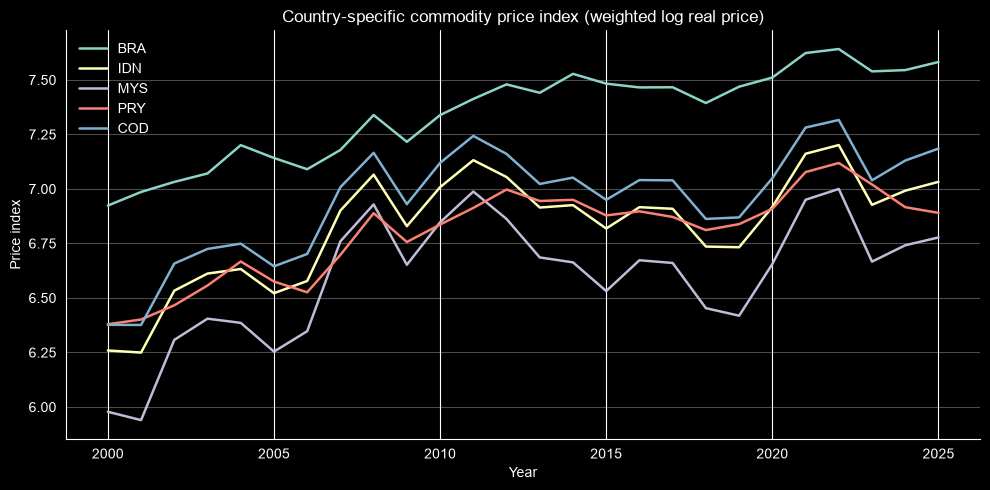

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for iso in ["BRA", "IDN", "MYS", "PRY", "COD"]:
    d = price_index[price_index.iso3 == iso]
    ax.plot(d["year"], d["price_index"], label=iso, linewidth=1.8)
ax.set_title("Country-specific commodity price index (weighted log real price)")
ax.set_xlabel("Year")
ax.set_ylabel("Price index")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Analysis panel (country × year)

We add to the deforestation panel:
- the price index, its one-year lag and its change (`price_index`, `price_index_lag1`, `d_price_index`);
- the world log real price of each commodity, current and lagged (same for every country, useful for simple scatter plots);
- the baseline shares and the exposure intensity (`value_per_forest_ha`), which we can use to split the sample.

In [10]:
wide_p = (logp.pivot(index="year", columns="commodity", values="log_price_real")
          .rename(columns=lambda c: "log_p_" + c.lower().replace(" ", "_")))
wide_p = wide_p.join(wide_p.shift(1).add_suffix("_lag1")).reset_index()

wide_w = (weights.pivot(index="iso3", columns="commodity", values="share")
          .rename(columns=lambda c: "share_" + c.lower().replace(" ", "_")))
wide_w["value_per_forest_ha"] = weights.groupby("iso3")["value_per_forest_ha"].first()
wide_w = wide_w.reset_index()

panel = (defor.merge(price_index, on=["iso3", "year"], how="left")
              .merge(wide_p, on="year", how="left")
              .merge(wide_w, on="iso3", how="left")
              .sort_values(["iso3", "year"]))

panel.to_csv(PROCESSED + "analysis_panel.csv", index=False)
print("Exported analysis_panel.csv:", panel.shape)
print("Same number of rows as the deforestation panel:", len(panel) == len(defor))
panel.isna().sum()[lambda s: s > 0]

Exported analysis_panel.csv: (1575, 24)
Same number of rows as the deforestation panel: True


price_index            25
price_index_lag1       25
d_price_index          25
share_beef             25
share_palm_oil         25
share_soybeans         25
value_per_forest_ha    25
dtype: int64

### 4.1 First look: correlations with the tree cover loss rate

In [11]:
cols = ["log_loss_rate", "log_agri_loss_rate", "price_index", "price_index_lag1", "d_price_index",
        "log_p_soybeans_lag1", "log_p_palm_oil_lag1", "log_p_beef_lag1"]
panel[cols].corr().loc[["log_loss_rate", "log_agri_loss_rate"]].round(2).T

,log_loss_rate,log_agri_loss_rate
log_loss_rate,1.00,0.83
log_agri_loss_rate,0.83,1.00
price_index,-0.08,0.00
price_index_lag1,-0.07,0.01
d_price_index,-0.05,-0.03
log_p_soybeans_lag1,0.20,0.12
log_p_palm_oil_lag1,0.16,0.11
log_p_beef_lag1,0.26,0.12


These are raw correlations: they mix differences *between* countries with changes *over time* within a country.
The bivariate analysis should therefore also look at within-country variation (demeaning by country), before moving to the panel regression with country and year fixed effects.